<a href="https://colab.research.google.com/github/sabharwal-monish/Deep-Learning-Tensor-Flow/blob/main/mobilenet_transferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [4]:
IMAGE_SHAPE = (224, 224)


classifier = hub.KerasLayer(
    "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4",
    input_shape=IMAGE_SHAPE + (3,)
)


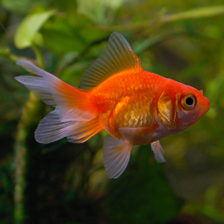

In [7]:
gold_fish = Image.open("goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [8]:
gold_fish = np.array(gold_fish)/225
gold_fish.shape

(224, 224, 3)

In [9]:
gold_fish[np.newaxis, ...]

array([[[[0.32      , 0.37777778, 0.08      ],
         [0.35555556, 0.42222222, 0.10222222],
         [0.39555556, 0.47555556, 0.13333333],
         ...,
         [0.37333333, 0.44444444, 0.00444444],
         [0.36444444, 0.43555556, 0.00444444],
         [0.35111111, 0.41777778, 0.        ]],

        [[0.32444444, 0.37777778, 0.09333333],
         [0.36888889, 0.43111111, 0.12444444],
         [0.4       , 0.48      , 0.14666667],
         ...,
         [0.36444444, 0.43111111, 0.00444444],
         [0.35555556, 0.42222222, 0.00444444],
         [0.34222222, 0.40888889, 0.        ]],

        [[0.32444444, 0.37777778, 0.09777778],
         [0.35555556, 0.41777778, 0.11555556],
         [0.39111111, 0.47111111, 0.14666667],
         ...,
         [0.36      , 0.42666667, 0.00444444],
         [0.35111111, 0.41777778, 0.00888889],
         [0.33777778, 0.40444444, 0.00444444]],

        ...,

        [[0.06222222, 0.12444444, 0.01777778],
         [0.05777778, 0.12888889, 0.02222222]

In [11]:
result = classifier(gold_fish[np.newaxis, ...])
result


<tf.Tensor: shape=(1, 1001), dtype=float32, numpy=
array([[ 0.23380849,  2.0063143 ,  9.744322  , ..., -1.5737591 ,
        -0.26879942, -0.225367  ]], dtype=float32)>

In [13]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(2)

In [14]:
image_labels = []
with open ('ImageNetLabels.txt', 'r') as f:
  image_labels = f.read().splitlines()


image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [16]:
image_labels[predicted_label_index]

'goldfish'

In [17]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [18]:
import pathlib
data_dir = pathlib.Path("/root/.keras/datasets/flower_photos/flower_photos")

print(data_dir)

/root/.keras/datasets/flower_photos/flower_photos


In [19]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/9231555352_d2dd8f8e68_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/8292914969_4a76608250_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/3749090865_b90f28a585_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/13096076565_72c2c60875_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/1244774242_25a20d99a9.jpg')]

In [20]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [21]:
(list(data_dir.glob('roses/*.jpg')))


[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2535466143_5823e48b63.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/165985535_7178ce6350.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3751835302_d5a03f55e8_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/9167147034_0a66ee3616_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/4713533500_fcc295de70_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/15712574834_2f121c7cf9_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2414954629_3708a1a04d.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3526860692_4c551191b1_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/5273722065_c85d8543c2_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/272481307_1eb47ba3e0_n.jpg'),
 PosixPath('/root

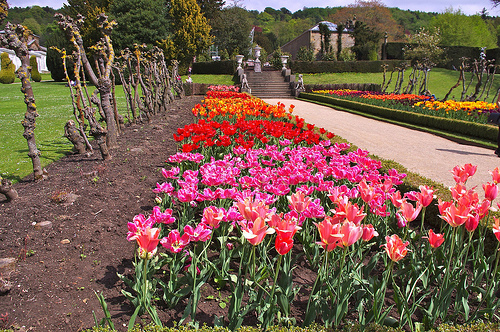

In [24]:
import PIL

tulips = list(data_dir.glob('tulips/*.jpg'))
PIL.Image.open(str(tulips[0]))

In [26]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}



In [27]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [28]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [29]:
X = np.array(X)
y = np.array(y)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [31]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [38]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, Model


feature_extractor_url = "https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/5"


feature_extractor_layer = hub.KerasLayer(
    feature_extractor_url,
    input_shape=(224, 224, 3),
    trainable=False
)


inputs = tf.keras.Input(shape=(224, 224, 3))
x = layers.Lambda(lambda data: feature_extractor_layer(data))(inputs)
outputs = layers.Dense(5, activation='softmax')(x)

model = Model(inputs, outputs)


model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,405 (25.02 KB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 70s 761ms/step - accuracy: 0.3433 - loss: 1.5292
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 76s 695ms/step - accuracy: 0.5229 - loss: 1.2009
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 58s 679ms/step - accuracy: 0.5933 - loss: 1.0772
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 698ms/step - accuracy: 0.5966 - loss: 1.0493
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 79s 667ms/step - accuracy: 0.6276 - loss: 0.9658


In [40]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 651ms/step - accuracy: 0.4590 - loss: 1.5524


[1.5664702653884888, 0.465141624212265]

In [42]:
y_pred = model.predict(X_test[:10])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# pick any test image index, say 7
index = 7

# get the image and true label
img = X_test[index]
true_label = y_test[index]

# expand dimensions to make it (1, 224, 224, 3)
img_expanded = np.expand_dims(img, axis=0)

# make prediction
y_pred = model.predict(img_expanded)

# get predicted class index
pred_class = np.argmax(y_pred, axis=1)[0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step


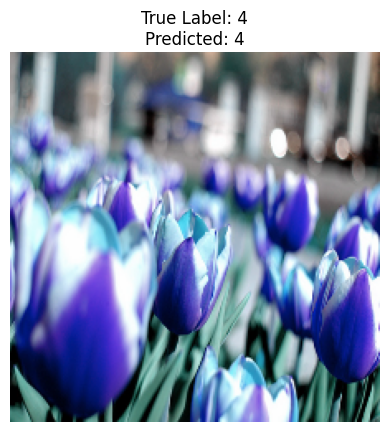

In [44]:
plt.imshow(img.astype("uint8"))   # or just plt.imshow(img)
plt.axis('off')

plt.title(f"True Label: {true_label}\nPredicted: {pred_class}")
plt.show()
